In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("orings.csv")
print(df.head())

   mission  temperature  damaged  undamaged
0        1           53        5          1
1        2           57        1          5
2        3           58        1          5
3        4           63        1          5
4        5           66        0          6


[1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


<function matplotlib.pyplot.show(close=None, block=None)>

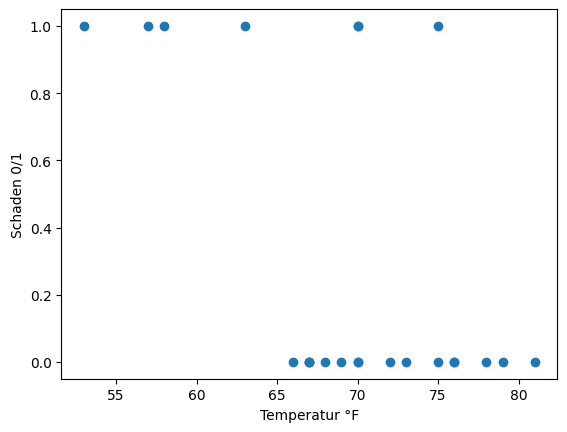

In [6]:
temp = df["temperature"].values.astype(float) # float für berechungen später
damaged = df["damaged"].values

y = (damaged > 0).astype(float) #astype wandelt True in 1.0 und False in 0.0
print(y)
plt.scatter(temp, y)
plt.xlabel("Temperatur °F"); plt.ylabel("Schaden 0/1")
plt.show

In [12]:
n = len(temp)

def sigmoid(z):
    return 1.0 /(1.0+np.exp(-z))

def predict(w0,w1, x):
    return sigmoid(w0 + w1*x)

def cost(w0, w1):

    J = 0.0 # Akkumulator, startet bei 0

    for i in range(n): # Schleife läuft über alle datenpunkte
        h = predict(w0, w1, temp[i])
        J += y[i] * np.log(h) + (1-y[i]) * np.log(1-h) # J = J + ...

    return -J/n    # mitteln und Vorzeichen drehen

def gradients(w0, w1):

    g0 = 0.0
    g1 = 0.0
    
    for i in range(n):
        error = predict(w0, w1, temp[i]) - y[i] # Wie weit liegt die Vorhersage daneben? Positiv = zu hoch, negativ = zu niedrig

        g0 += error
        g1 += error *temp[i]


    return g0/n, g1/n


w0, w1 = 0.0, 0.0
lr = 0.001 #Lernrate
epochs = 200000

for epoch in range(epochs):
    g0, g1 = gradients(w0, w1)
    w0 -= lr * g0
    w1 -= lr * g1

    if epoch % 20000 ==0:
        print(f"Epoch{epoch:6d} | J = {cost(w0, w1):.4f} | w0 = {w0:.4f}, w1 = {w1:.4f}")



Epoch     0 | J = 0.5943 | w0 = -0.0002, w1 = -0.0154
Epoch 20000 | J = 0.5819 | w0 = 0.4643, w1 = -0.0202
Epoch 40000 | J = 0.5719 | w0 = 0.9102, w1 = -0.0266
Epoch 60000 | J = 0.5628 | w0 = 1.3381, w1 = -0.0327
Epoch 80000 | J = 0.5543 | w0 = 1.7487, w1 = -0.0386
Epoch100000 | J = 0.5466 | w0 = 2.1427, w1 = -0.0443
Epoch120000 | J = 0.5394 | w0 = 2.5206, w1 = -0.0497
Epoch140000 | J = 0.5329 | w0 = 2.8833, w1 = -0.0550
Epoch160000 | J = 0.5268 | w0 = 3.2314, w1 = -0.0600
Epoch180000 | J = 0.5212 | w0 = 3.5656, w1 = -0.0648


In [15]:
print(f"P(Schaden | 80°F) = {predict(w0,w1, 80):.4f}")

P(Schaden | 80°F) = 0.1583


In [18]:
# Mit Standardisierung
temp_mean = temp.mean()
temp_std  = temp.std()
temp_s = (temp - temp_mean) / temp_std   # z-transformiert: Mittelwert 0, Std 1

n = len(temp_s)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def predict(w0, w1, x):
    return sigmoid(w0 + w1 * x)

def cost(w0, w1):
    J = 0.0
    for i in range(n):
        h = predict(w0, w1, temp_s[i])           #  temp_s statt temp
        J += y[i] * np.log(h) + (1 - y[i]) * np.log(1 - h)
    return -J / n

def gradients(w0, w1):
    g0 = 0.0
    g1 = 0.0
    for i in range(n):
        error = predict(w0, w1, temp_s[i]) - y[i]   # temp_s
        g0 += error
        g1 += error * temp_s[i]                     # temp_s
    return g0 / n, g1 / n

# Training
w0, w1 = 0.0, 0.0
lr = 0.1           # Lernrate
epochs = 20000     # Schritte

for epoch in range(epochs):
    g0, g1 = gradients(w0, w1)
    w0 -= lr * g0
    w1 -= lr * g1
    if epoch % 2000 == 0:
        print(f"Epoch {epoch:6d} | J = {cost(w0, w1):.4f} | w0 = {w0:.4f}, w1 = {w1:.4f}")

#  Vorhersage: neue Temperatur muss auch standardisiert werden!
def predict_real(temp_celsius_or_f):
    x_s = (temp_celsius_or_f - temp_mean) / temp_std
    return predict(w0, w1, x_s)

print(f"\nP(Schaden | 31°F) = {predict_real(31):.4f}")
print("samuel")

Epoch      0 | J = 0.6828 | w0 = -0.0196, w1 = -0.0258
Epoch   2000 | J = 0.4416 | w0 = -1.1075, w1 = -1.6024
Epoch   4000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024
Epoch   6000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024
Epoch   8000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024
Epoch  10000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024
Epoch  12000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024
Epoch  14000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024
Epoch  16000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024
Epoch  18000 | J = 0.4416 | w0 = -1.1076, w1 = -1.6024

P(Schaden | 31°F) = 0.9996
samuel
